# 01 — Theorem 6 upper envelope vs simulation (hits)

Reads `result/table/01_theorem6_upper_bound_hits.csv` and saves a vector PDF to `result/figure/01_theorem6_upper_bound_hits.pdf`.

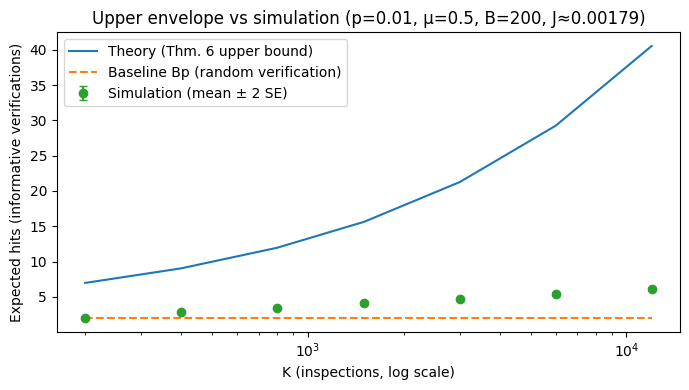

Saved: /home/leiyo/GitHub/Attention-Constrained-Leaderless-Inference/result/figure/01_theorem6_upper_bound_hits.pdf


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
csv_path = ROOT / "result" / "table" / "01_theorem6_upper_bound_hits.csv"
fig_path = ROOT / "result" / "figure" / "01_theorem6_upper_bound_hits.pdf"

df = pd.read_csv(csv_path).sort_values("K")

plt.rcParams["pdf.fonttype"] = 42
plt.figure(figsize=(7,4))
plt.plot(df["K"], df["theorem6_upper_bound_hits"], label="Theory (Thm. 6 upper bound)")
plt.plot(df["K"], df["baseline_Bp"], linestyle="--", label="Baseline Bp (random verification)")
plt.errorbar(df["K"], df["sim_E_hits"], yerr=2*df["sim_SE"], fmt="o", capsize=3, label="Simulation (mean ± 2 SE)")
plt.xscale("log")
plt.xlabel("K (inspections, log scale)")
plt.ylabel("Expected hits (informative verifications)")
plt.title(f"Upper envelope vs simulation (p={df.p.iloc[0]}, μ={df.mu.iloc[0]}, B={df.B.iloc[0]}, J≈{df.J.iloc[0]:.3g})")
plt.legend()
plt.tight_layout()
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, format="pdf")
plt.show()

print("Saved:", fig_path)
